In [1]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, Scene

In [2]:
scene = load_scene() # Load empty scene

# 2. Anten dizisi (tüm vericiler için ortak)
scene.tx_array = PlanarArray(
    num_rows=4,
    num_cols=4,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="tr38901",           # ← bu zorunlu
    polarization="VH"            # isteğe bağlı
) 

# 3. Kabinet verilerin çıkartılması

kabinets = [
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1073413,
        "Longitude": 29.0233668,
        "Azimuth": 50,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 10,
        "MIMO": "64T64R",
        "PCI": 30,
        "rachroot": 26,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1070873,
        "Longitude": 29.0226646,
        "Azimuth": 260,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 10,
        "MIMO": "64T64R",
        "PCI": 40,
        "rachroot": 126,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1080861,
        "Longitude": 29.028122,
        "Azimuth": 230,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 59,
        "rachroot": 42,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1080861,
        "Longitude": 29.0281222,
        "Azimuth": 110,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 48,
        "rachroot": 69,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1054694,
        "Longitude": 29.0278333,
        "Azimuth": 255,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 9.5,
        "Height": 18,
        "MIMO": "32T32R",
        "PCI": 68,
        "rachroot": 132,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1054694,
        "Longitude": 29.0278333,
        "Azimuth": 340,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 9.5,
        "Height": 18,
        "MIMO": "32T32R",
        "PCI": 76,
        "rachroot": 75,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1043417,
        "Longitude": 29.021747,
        "Azimuth": 300,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 3,
        "rachroot": 30,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1043417,
        "Longitude": 29.021747,
        "Azimuth": 40,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 13,
        "rachroot": 130,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1058417,
        "Longitude": 29.0205028,
        "Azimuth": 130,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 23,
        "rachroot": 93,
        "Power": 200,
        "Ssbpower": 17.91
    }
]
  # Kullanıcının sağladığı veri listesi

tx_objects = []
for kb in kabinets:
    pos = [kb["Longitude"], kb["Latitude"], kb["Height"]]
    tx = Transmitter(position=pos, power_dbm=kb["Power"], name=kb["PCI"])
    scene.add(tx)
    tx_objects.append(tx)

# 4. Alıcılar (örneğin bir grid tanımla)
xs = np.linspace(scene._scene_params.bounds.min[0], scene._scene_params.bounds.max[0], 200)
ys = np.linspace(scene._scene_params.bounds.min[1], scene._scene_params.bounds.max[1], 200)
rx_positions = np.stack(np.meshgrid(xs, ys, [1.5]), axis=-1).reshape(-1,3)
rx = Receiver(name="rx_dummy")
scene.add(rx)

# 5. RadioMapSolver ile harita çözümü
solver = RadioMapSolver(
    scene=scene,
    subcarriers=subcarrier_frequencies(3.5e9, 100e6, 41),
    sample_points=rx_positions,
    tx=tx_objects  # Liste olarak giriyoruz
)

radio_map = solver.solve()  # Her noktada her vericideki güç değerleri

# 6. Haritayı çiz
plt.figure(figsize=(8,6))
power_dbm = 10 * np.log10(np.sum(radio_map, axis=-1))
plt.scatter(rx_positions[:,0], rx_positions[:,1], c=power_dbm, s=4, cmap="viridis")
plt.colorbar(label="Toplam Güç (dBm)")
plt.title("Multi‑Transmitter Radyo Haritası")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

AttributeError: 'SceneParameters' object has no attribute 'bounds'

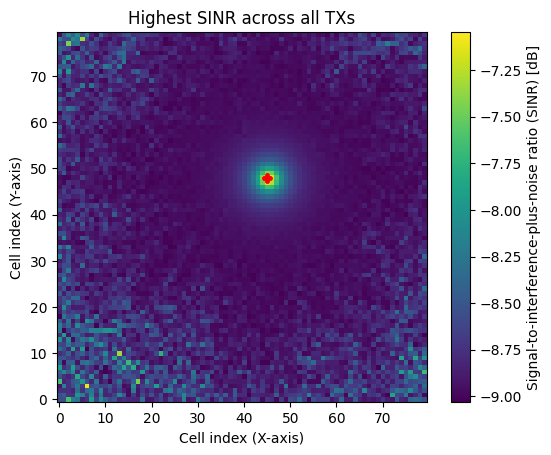

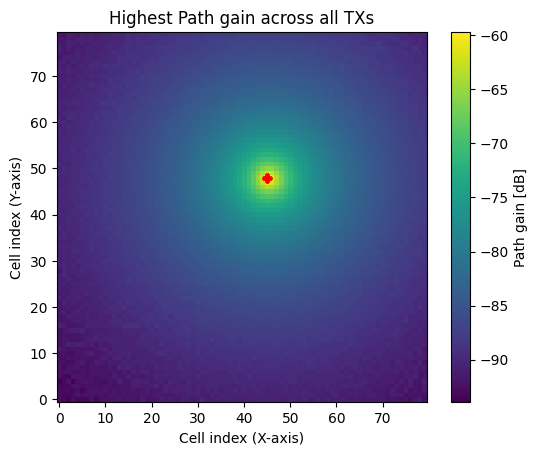

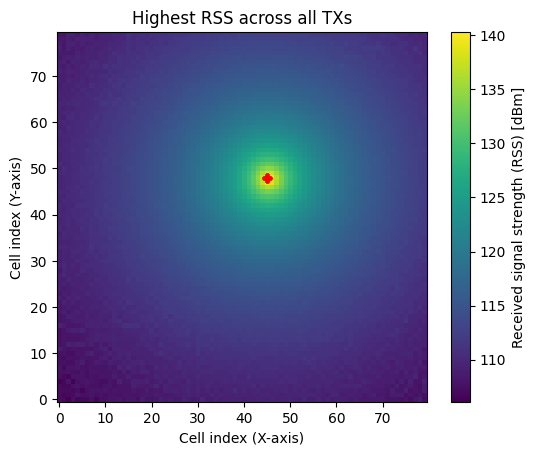

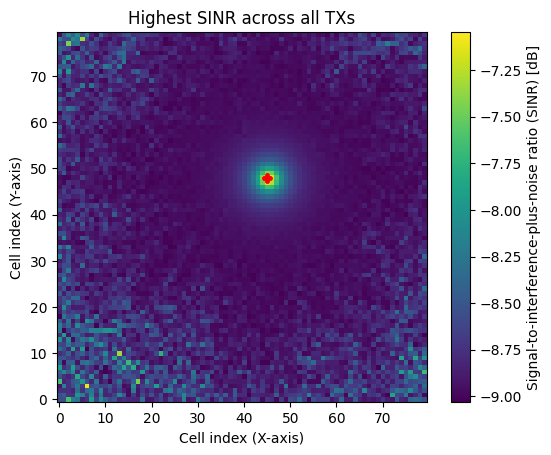

In [ ]:
# Visualize path gain
rm.show(metric="path_gain")

# Visualize received signal strength (RSS)
rm.show(metric="rss")

# Visulaize SINR
rm.show(metric="sinr")

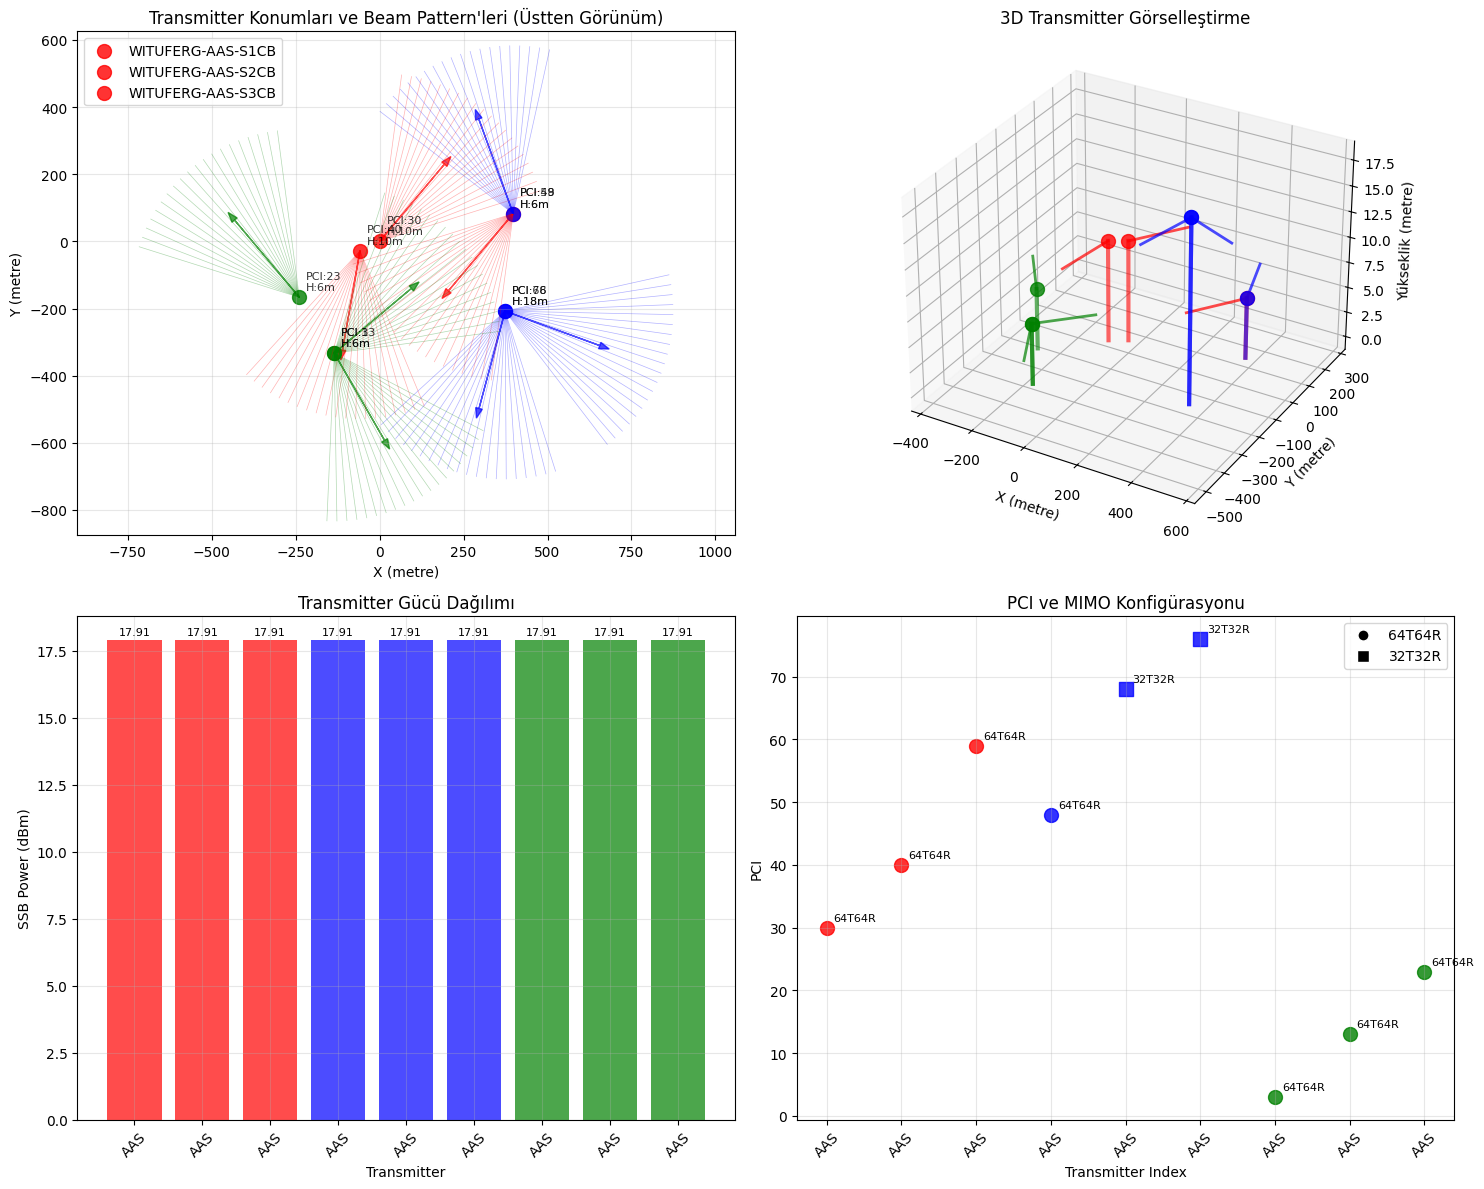


=== TRANSMITTER ÖZETİ ===
Toplam Transmitter Sayısı: 9
Kabinet Sayısı: 3
Ortalama Yükseklik: 9.6 metre
Ortalama SSB Power: 17.91 dBm

=== KABİNET BAZLI ÖZETİ ===

WITUPAG:
  - Sector Sayısı: 3
  - MIMO Tipleri: {'64T64R'}
  - Yükseklik Aralığı: 6-6 metre
  - PCI Aralığı: 3-23

WITUFESG:
  - Sector Sayısı: 3
  - MIMO Tipleri: {'32T32R', '64T64R'}
  - Yükseklik Aralığı: 6-18 metre
  - PCI Aralığı: 48-76

WITUFERG:
  - Sector Sayısı: 3
  - MIMO Tipleri: {'64T64R'}
  - Yükseklik Aralığı: 6-10 metre
  - PCI Aralığı: 30-59


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

# Kabinet verileri
kabinets = [
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1073413,
        "Longitude": 29.0233668,
        "Azimuth": 50,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 10,
        "MIMO": "64T64R",
        "PCI": 30,
        "rachroot": 26,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1070873,
        "Longitude": 29.0226646,
        "Azimuth": 260,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 10,
        "MIMO": "64T64R",
        "PCI": 40,
        "rachroot": 126,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1080861,
        "Longitude": 29.028122,
        "Azimuth": 230,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 59,
        "rachroot": 42,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1080861,
        "Longitude": 29.0281222,
        "Azimuth": 110,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 48,
        "rachroot": 69,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1054694,
        "Longitude": 29.0278333,
        "Azimuth": 255,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 9.5,
        "Height": 18,
        "MIMO": "32T32R",
        "PCI": 68,
        "rachroot": 132,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1054694,
        "Longitude": 29.0278333,
        "Azimuth": 340,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 9.5,
        "Height": 18,
        "MIMO": "32T32R",
        "PCI": 76,
        "rachroot": 75,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1043417,
        "Longitude": 29.021747,
        "Azimuth": 300,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 3,
        "rachroot": 30,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1043417,
        "Longitude": 29.021747,
        "Azimuth": 40,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 13,
        "rachroot": 130,
        "Power": 200,
        "Ssbpower": 17.91
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1058417,
        "Longitude": 29.0205028,
        "Azimuth": 130,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 23,
        "rachroot": 93,
        "Power": 200,
        "Ssbpower": 17.91
    }
]

def lat_lon_to_xy(lat, lon, origin_lat, origin_lon):
    """Coğrafi koordinatları yerel kartezyen koordinatlara dönüştür"""
    # Yaklaşık olarak 1 derece = 111000 metre
    x = (lon - origin_lon) * 111000 * math.cos(math.radians(origin_lat))
    y = (lat - origin_lat) * 111000
    return x, y

def create_beam_pattern(azimuth, h_beamwidth, beam_length=500):
    """Anten beam pattern'i oluştur"""
    # Azimuth açısını radyana çevir
    azimuth_rad = math.radians(azimuth)
    h_beamwidth_rad = math.radians(h_beamwidth)
    
    # Beam kenarlarını hesapla
    left_angle = azimuth_rad - h_beamwidth_rad/2
    right_angle = azimuth_rad + h_beamwidth_rad/2
    
    # Beam çizgileri için noktalar
    angles = np.linspace(left_angle, right_angle, 20)
    x_beam = beam_length * np.cos(angles)
    y_beam = beam_length * np.sin(angles)
    
    return x_beam, y_beam

# Görselleştirme için figür oluştur
fig = plt.figure(figsize=(15, 12))

# 2D plot (üstten görünüm)
ax1 = plt.subplot(2, 2, 1)
ax1.set_title('Transmitter Konumları ve Beam Pattern\'leri (Üstten Görünüm)', fontsize=12)

# 3D plot
ax3d = plt.subplot(2, 2, 2, projection='3d')
ax3d.set_title('3D Transmitter Görselleştirme', fontsize=12)

# Güç dağılımı plot
ax2 = plt.subplot(2, 2, 3)
ax2.set_title('Transmitter Gücü Dağılımı', fontsize=12)

# PCI dağılımı plot
ax4 = plt.subplot(2, 2, 4)
ax4.set_title('PCI ve MIMO Konfigürasyonu', fontsize=12)

# Referans noktası (ilk transmitter)
origin_lat = kabinets[0]["Latitude"]
origin_lon = kabinets[0]["Longitude"]

# Renkler için kabinet bazlı mapping
kabinet_colors = {
    "WITUFERG": 'red',
    "WITUFESG": 'blue',
    "WITUPAG": 'green'
}

# Her transmitter için işlem
for i, tx in enumerate(kabinets):
    # Koordinat dönüşümü
    x, y = lat_lon_to_xy(tx["Latitude"], tx["Longitude"], origin_lat, origin_lon)
    
    # Renk seçimi
    color = kabinet_colors[tx["Kabinet"]]
    
    # 2D Plot - Transmitter konumu
    ax1.scatter(x, y, c=color, s=100, alpha=0.8, 
                label=f'{tx["Kabinet"]}-{tx["Sector"]}' if i < 3 else "")
    
    # Beam pattern çizimi
    x_beam, y_beam = create_beam_pattern(tx["Azimuth"], tx["Horizontal_Beamwidth"])
    for j in range(len(x_beam)):
        ax1.plot([x, x + x_beam[j]], [y, y + y_beam[j]], 
                color=color, alpha=0.3, linewidth=0.5)
    
    # Ana beam direction
    beam_x = 300 * math.cos(math.radians(tx["Azimuth"]))
    beam_y = 300 * math.sin(math.radians(tx["Azimuth"]))
    ax1.arrow(x, y, beam_x, beam_y, head_width=20, head_length=30, 
              fc=color, ec=color, alpha=0.7)
    
    # Transmitter bilgileri
    ax1.annotate(f'PCI:{tx["PCI"]}\nH:{tx["Height"]}m', 
                xy=(x, y), xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)
    
    # 3D Plot
    ax3d.scatter(x, y, tx["Height"], c=color, s=100, alpha=0.8)
    
    # 3D'de dikey çubuk (yükseklik gösterimi)
    ax3d.plot([x, x], [y, y], [0, tx["Height"]], color=color, alpha=0.6, linewidth=3)
    
    # 3D'de beam direction
    beam_x_3d = 200 * math.cos(math.radians(tx["Azimuth"]))
    beam_y_3d = 200 * math.sin(math.radians(tx["Azimuth"]))
    ax3d.plot([x, x + beam_x_3d], [y, y + beam_y_3d], 
              [tx["Height"], tx["Height"]], color=color, alpha=0.7, linewidth=2)

# 2D plot ayarları
ax1.set_xlabel('X (metre)')
ax1.set_ylabel('Y (metre)')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axis('equal')

# 3D plot ayarları
ax3d.set_xlabel('X (metre)')
ax3d.set_ylabel('Y (metre)')
ax3d.set_zlabel('Yükseklik (metre)')
ax3d.grid(True, alpha=0.3)

# Güç dağılımı plot
sectors = [f"{tx['Kabinet']}-{tx['Sector']}" for tx in kabinets]
powers = [tx["Ssbpower"] for tx in kabinets]
colors_power = [kabinet_colors[tx["Kabinet"]] for tx in kabinets]

bars = ax2.bar(range(len(sectors)), powers, color=colors_power, alpha=0.7)
ax2.set_xlabel('Transmitter')
ax2.set_ylabel('SSB Power (dBm)')
ax2.set_xticks(range(len(sectors)))
ax2.set_xticklabels([s.split('-')[1] for s in sectors], rotation=45)
ax2.grid(True, alpha=0.3)

# Her bar üzerine değer yazma
for bar, power in zip(bars, powers):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{power}', ha='center', va='bottom', fontsize=8)

# PCI ve MIMO dağılımı
pci_values = [tx["PCI"] for tx in kabinets]
mimo_types = [tx["MIMO"] for tx in kabinets]
colors_pci = [kabinet_colors[tx["Kabinet"]] for tx in kabinets]

# MIMO tipine göre marker şekli
mimo_markers = {'64T64R': 'o', '32T32R': 's'}
for i, (pci, mimo, color) in enumerate(zip(pci_values, mimo_types, colors_pci)):
    marker = mimo_markers.get(mimo, 'o')
    ax4.scatter(i, pci, c=color, s=100, marker=marker, alpha=0.8)
    ax4.annotate(f'{mimo}', xy=(i, pci), xytext=(5, 5), 
                textcoords='offset points', fontsize=8)

ax4.set_xlabel('Transmitter Index')
ax4.set_ylabel('PCI')
ax4.set_xticks(range(len(sectors)))
ax4.set_xticklabels([s.split('-')[1] for s in sectors], rotation=45)
ax4.grid(True, alpha=0.3)

# MIMO legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                         markersize=8, label='64T64R'),
                  Line2D([0], [0], marker='s', color='w', markerfacecolor='black', 
                         markersize=8, label='32T32R')]
ax4.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Özet bilgiler yazdır
print("\n=== TRANSMITTER ÖZETİ ===")
print(f"Toplam Transmitter Sayısı: {len(kabinets)}")
print(f"Kabinet Sayısı: {len(set(tx['Kabinet'] for tx in kabinets))}")
print(f"Ortalama Yükseklik: {np.mean([tx['Height'] for tx in kabinets]):.1f} metre")
print(f"Ortalama SSB Power: {np.mean([tx['Ssbpower'] for tx in kabinets]):.2f} dBm")

print("\n=== KABİNET BAZLI ÖZETİ ===")
for kabinet_name in set(tx['Kabinet'] for tx in kabinets):
    kabinet_txs = [tx for tx in kabinets if tx['Kabinet'] == kabinet_name]
    print(f"\n{kabinet_name}:")
    print(f"  - Sector Sayısı: {len(kabinet_txs)}")
    print(f"  - MIMO Tipleri: {set(tx['MIMO'] for tx in kabinet_txs)}")
    print(f"  - Yükseklik Aralığı: {min(tx['Height'] for tx in kabinet_txs)}-{max(tx['Height'] for tx in kabinet_txs)} metre")
    print(f"  - PCI Aralığı: {min(tx['PCI'] for tx in kabinet_txs)}-{max(tx['PCI'] for tx in kabinet_txs)}")

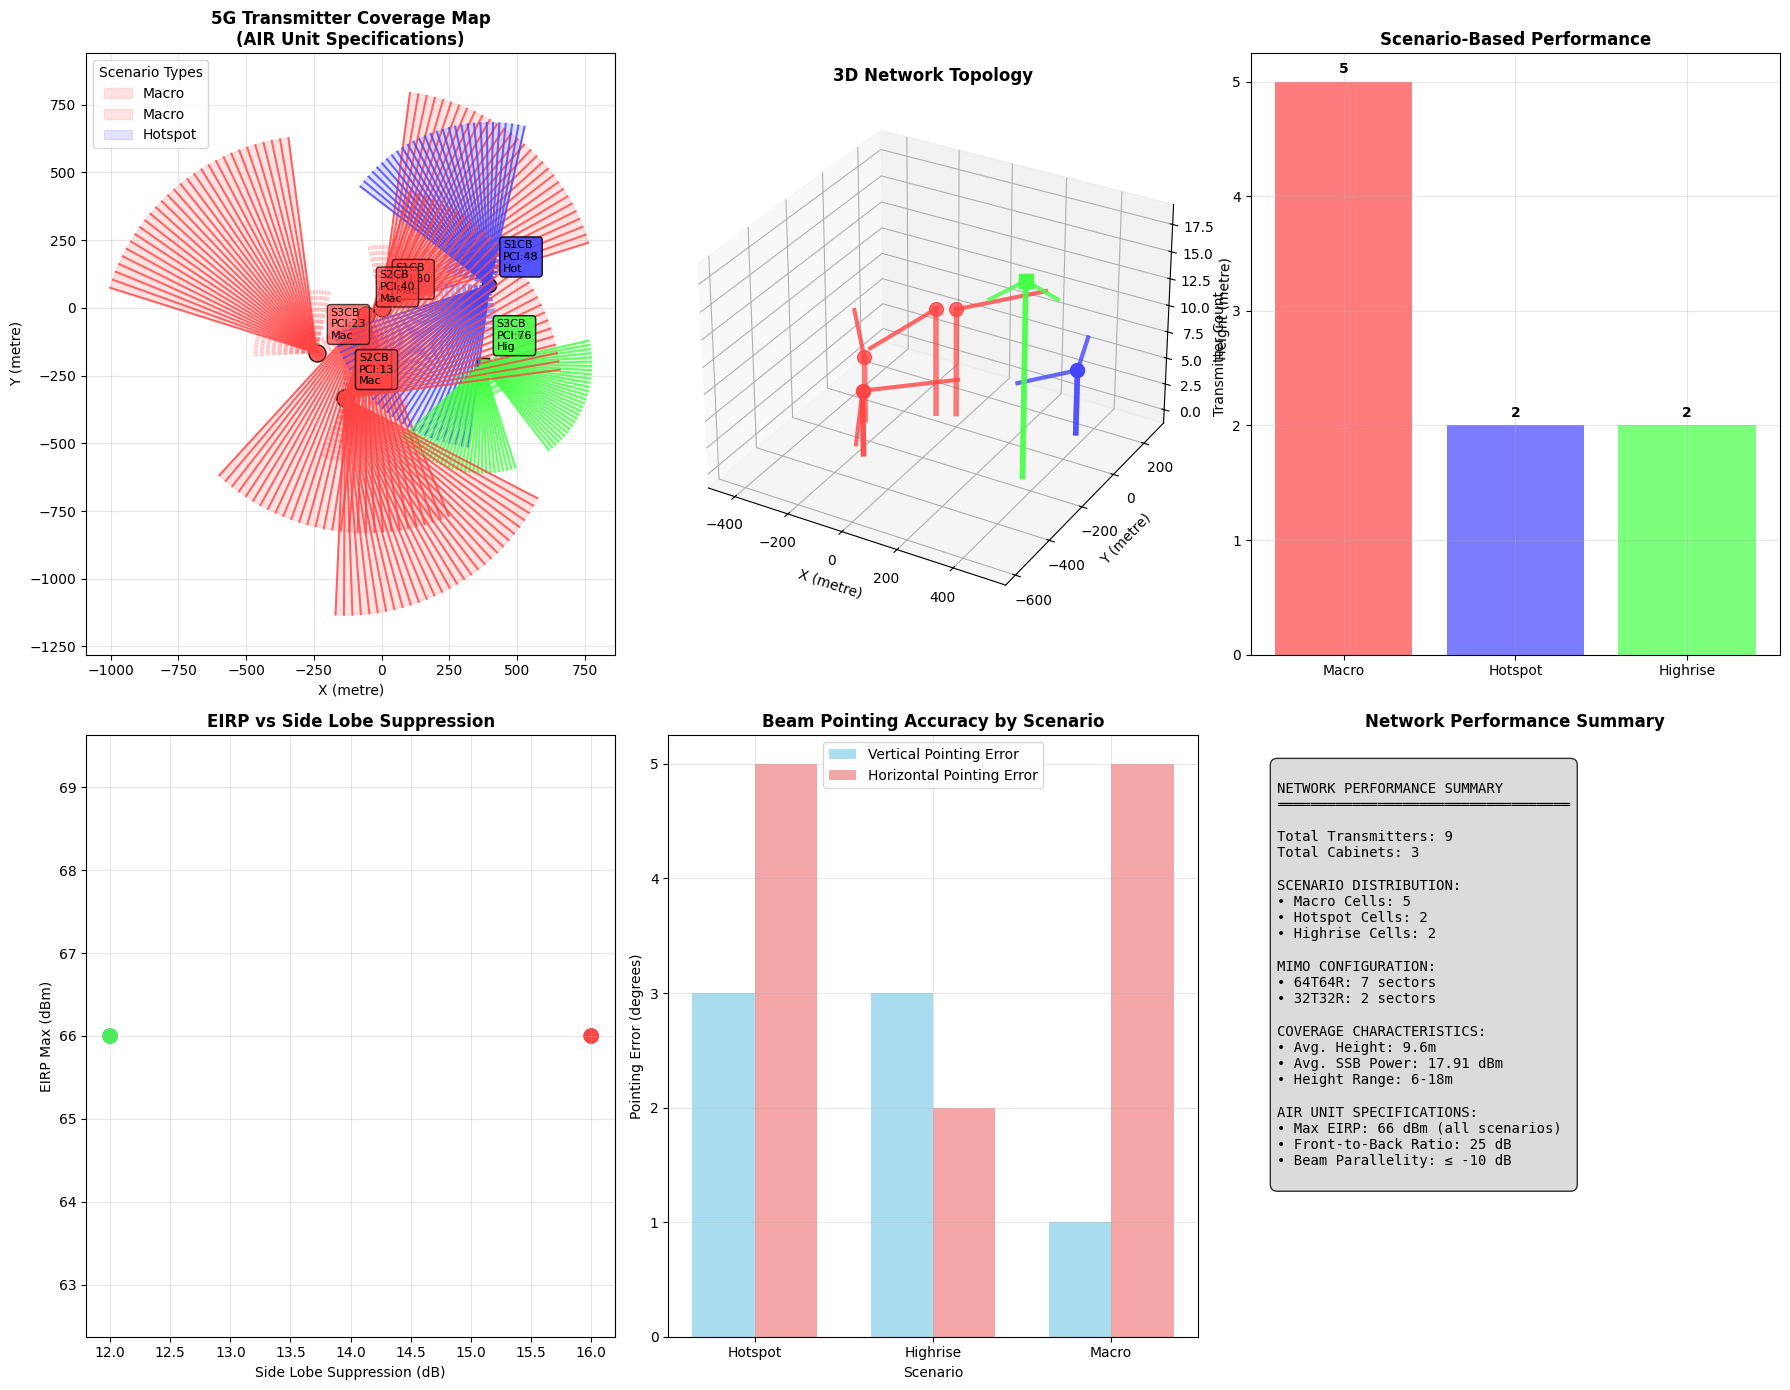


5G NETWORK PERFORMANCE ANALYSIS - AIR UNIT SPECIFICATIONS

MACRO SCENARIO ANALYSIS:
──────────────────────────────────────────────────
Transmitter Count: 5
AIR Unit Specifications:
  • Vertical Beamwidth: 10°
  • Horizontal Beamwidth: 65°
  • Digital Downtilt: [-8, 8]
  • Side Lobe Suppression: 16 dB
  • EIRP Max: 66 dBm
  • Front-to-Back Ratio: 25 dB

Deployment Characteristics:
  • Avg Height: 7.6 m
  • Height Range: 6-10 m
  • MIMO Types: {'64T64R'}
  • PCI Range: 3-40

HOTSPOT SCENARIO ANALYSIS:
──────────────────────────────────────────────────
Transmitter Count: 2
AIR Unit Specifications:
  • Vertical Beamwidth: 30°
  • Horizontal Beamwidth: 65°
  • Digital Downtilt: Fixed 3°
  • Side Lobe Suppression: 12 dB
  • EIRP Max: 66 dBm
  • Front-to-Back Ratio: 25 dB

Deployment Characteristics:
  • Avg Height: 6.0 m
  • Height Range: 6-6 m
  • MIMO Types: {'64T64R'}
  • PCI Range: 48-59

HIGHRISE SCENARIO ANALYSIS:
──────────────────────────────────────────────────
Transmitter Count: 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

# Kabinet verileri
kabinets = [
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1073413,
        "Longitude": 29.0233668,
        "Azimuth": 50,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 10,
        "MIMO": "64T64R",
        "PCI": 30,
        "rachroot": 26,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    },
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1070873,
        "Longitude": 29.0226646,
        "Azimuth": 260,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 10,
        "MIMO": "64T64R",
        "PCI": 40,
        "rachroot": 126,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    },
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1080861,
        "Longitude": 29.028122,
        "Azimuth": 230,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 59,
        "rachroot": 42,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Hotspot"
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1080861,
        "Longitude": 29.0281222,
        "Azimuth": 110,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 48,
        "rachroot": 69,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Hotspot"
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1054694,
        "Longitude": 29.0278333,
        "Azimuth": 255,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 9.5,
        "Height": 18,
        "MIMO": "32T32R",
        "PCI": 68,
        "rachroot": 132,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Highrise"
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1054694,
        "Longitude": 29.0278333,
        "Azimuth": 340,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 9.5,
        "Height": 18,
        "MIMO": "32T32R",
        "PCI": 76,
        "rachroot": 75,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Highrise"
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1043417,
        "Longitude": 29.021747,
        "Azimuth": 300,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 3,
        "rachroot": 30,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1043417,
        "Longitude": 29.021747,
        "Azimuth": 40,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 13,
        "rachroot": 130,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1058417,
        "Longitude": 29.0205028,
        "Azimuth": 130,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 23,
        "rachroot": 93,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    }
]

# AIR Unit Performans Verileri
air_performance = {
    "Macro": {
        "Vertical_Beamwidth": 10,  # ±1°
        "Horizontal_Beamwidth": 65,  # ±5°
        "Digital_Downtilt": "[-8, 8]",
        "Vertical_Beam_Pointing_Error": 1,
        "Horizontal_Beam_Pointing": 5,
        "EIRP_max": 66,  # dBm
        "Side_Lobe_Suppression": 16,  # dB (vertical)
        "Front_to_Back_Ratio": 25,  # dB
        "Beam_Parallelity": -10  # dB
    },
    "Hotspot": {
        "Vertical_Beamwidth": 30,  # ±3°
        "Horizontal_Beamwidth": 65,  # ±5°
        "Digital_Downtilt": "Fixed 3°",
        "Vertical_Beam_Pointing_Error": 3,
        "Horizontal_Beam_Pointing": 5,
        "EIRP_max": 66,  # dBm
        "Side_Lobe_Suppression": 12,  # dB (vertical)
        "Front_to_Back_Ratio": 25,  # dB
        "Beam_Parallelity": -10  # dB
    },
    "Highrise": {
        "Vertical_Beamwidth": 30,  # ±3°
        "Horizontal_Beamwidth": 20,  # ±2°
        "Digital_Downtilt": "Fixed 3°",
        "Vertical_Beam_Pointing_Error": 3,
        "Horizontal_Beam_Pointing": 2,
        "EIRP_max": 66,  # dBm
        "Side_Lobe_Suppression": 12,  # dB (horizontal)
        "Front_to_Back_Ratio": 25,  # dB
        "Beam_Parallelity": -10  # dB
    }
}

def lat_lon_to_xy(lat, lon, origin_lat, origin_lon):
    """Coğrafi koordinatları yerel kartezyen koordinatlara dönüştür"""
    x = (lon - origin_lon) * 111000 * math.cos(math.radians(origin_lat))
    y = (lat - origin_lat) * 111000
    return x, y

def create_realistic_beam_pattern(azimuth, h_beamwidth, scenario, beam_length=800):
    """Gerçekçi anten beam pattern'i oluştur - AIR Unit specs'e göre"""
    azimuth_rad = math.radians(azimuth)
    h_beamwidth_rad = math.radians(h_beamwidth)
    
    # Scenario'ya göre beam karakteristiği
    if scenario == "Highrise":
        beam_length = 400  # Daha kısa range
    elif scenario == "Hotspot":
        beam_length = 600  # Orta range
    
    # Ana beam (3dB beamwidth)
    left_angle = azimuth_rad - h_beamwidth_rad/2
    right_angle = azimuth_rad + h_beamwidth_rad/2
    
    # Ana beam
    angles_main = np.linspace(left_angle, right_angle, 30)
    x_main = beam_length * np.cos(angles_main)
    y_main = beam_length * np.sin(angles_main)
    
    # Side lobe'lar (daha düşük güç)
    side_lobe_length = beam_length * 0.3  # Side lobe suppression
    
    # Sol side lobe
    left_side_start = left_angle - math.radians(20)
    left_side_end = left_angle
    angles_left = np.linspace(left_side_start, left_side_end, 15)
    x_left = side_lobe_length * np.cos(angles_left)
    y_left = side_lobe_length * np.sin(angles_left)
    
    # Sağ side lobe
    right_side_start = right_angle
    right_side_end = right_angle + math.radians(20)
    angles_right = np.linspace(right_side_start, right_side_end, 15)
    x_right = side_lobe_length * np.cos(angles_right)
    y_right = side_lobe_length * np.sin(angles_right)
    
    return (x_main, y_main), (x_left, y_left), (x_right, y_right)

def calculate_coverage_area(x, y, azimuth, h_beamwidth, scenario, beam_range=800):
    """Coverage area hesaplama"""
    if scenario == "Highrise":
        beam_range = 400
    elif scenario == "Hotspot":
        beam_range = 600
    
    azimuth_rad = math.radians(azimuth)
    h_beamwidth_rad = math.radians(h_beamwidth)
    
    # Coverage sektörü
    angles = np.linspace(azimuth_rad - h_beamwidth_rad/2, 
                        azimuth_rad + h_beamwidth_rad/2, 50)
    
    # Yarım daire coverage
    coverage_x = []
    coverage_y = []
    
    for angle in angles:
        coverage_x.append(x + beam_range * np.cos(angle))
        coverage_y.append(y + beam_range * np.sin(angle))
    
    # Merkeze geri dön
    coverage_x.append(x)
    coverage_y.append(y)
    
    return coverage_x, coverage_y

# Görselleştirme
fig = plt.figure(figsize=(18, 14))

# Ana 2D plot (coverage haritası)
ax1 = plt.subplot(2, 3, 1)
ax1.set_title('5G Transmitter Coverage Map\n(AIR Unit Specifications)', fontsize=12, fontweight='bold')

# 3D plot
ax3d = plt.subplot(2, 3, 2, projection='3d')
ax3d.set_title('3D Network Topology', fontsize=12, fontweight='bold')

# Scenario bazlı analiz
ax2 = plt.subplot(2, 3, 3)
ax2.set_title('Scenario-Based Performance', fontsize=12, fontweight='bold')

# EIRP ve Side Lobe Analizi
ax4 = plt.subplot(2, 3, 4)
ax4.set_title('EIRP vs Side Lobe Suppression', fontsize=12, fontweight='bold')

# Beam Pointing Accuracy
ax5 = plt.subplot(2, 3, 5)
ax5.set_title('Beam Pointing Accuracy by Scenario', fontsize=12, fontweight='bold')

# Network Performance Summary
ax6 = plt.subplot(2, 3, 6)
ax6.set_title('Network Performance Summary', fontsize=12, fontweight='bold')

# Referans noktası
origin_lat = kabinets[0]["Latitude"]
origin_lon = kabinets[0]["Longitude"]

# Renkler
scenario_colors = {
    "Macro": '#FF4444',      # Kırmızı
    "Hotspot": '#4444FF',    # Mavi  
    "Highrise": '#44FF44'    # Yeşil
}

# Her transmitter için işlem
for i, tx in enumerate(kabinets):
    x, y = lat_lon_to_xy(tx["Latitude"], tx["Longitude"], origin_lat, origin_lon)
    
    scenario = tx["Scenario"]
    color = scenario_colors[scenario]
    
    # Gerçekçi beam pattern
    (x_main, y_main), (x_left, y_left), (x_right, y_right) = create_realistic_beam_pattern(
        tx["Azimuth"], tx["Horizontal_Beamwidth"], scenario)
    
    # Coverage area
    coverage_x, coverage_y = calculate_coverage_area(
        x, y, tx["Azimuth"], tx["Horizontal_Beamwidth"], scenario)
    
    # 2D Plot - Coverage
    ax1.fill(coverage_x, coverage_y, color=color, alpha=0.15, label=scenario if i < 3 else "")
    
    # Ana beam
    for j in range(len(x_main)):
        ax1.plot([x, x + x_main[j]], [y, y + y_main[j]], 
                color=color, alpha=0.8, linewidth=1.5)
    
    # Side lobes
    for j in range(len(x_left)):
        ax1.plot([x, x + x_left[j]], [y, y + y_left[j]], 
                color=color, alpha=0.3, linewidth=0.8, linestyle='--')
    for j in range(len(x_right)):
        ax1.plot([x, x + x_right[j]], [y, y + y_right[j]], 
                color=color, alpha=0.3, linewidth=0.8, linestyle='--')
    
    # Transmitter konumu
    marker_size = 150 if scenario == "Macro" else 100 if scenario == "Hotspot" else 80
    ax1.scatter(x, y, c=color, s=marker_size, alpha=0.9, edgecolors='black', linewidth=1,
               marker='o' if tx["MIMO"] == "64T64R" else 's')
    
    # Bilgi etiketi
    ax1.annotate(f'{tx["Sector"].split("-")[1]}\nPCI:{tx["PCI"]}\n{scenario[:3]}', 
                xy=(x, y), xytext=(10, 10), textcoords='offset points',
                fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7))
    
    # 3D Plot
    ax3d.scatter(x, y, tx["Height"], c=color, s=100, alpha=0.8,
                marker='o' if tx["MIMO"] == "64T64R" else 's')
    
    # Yükseklik çubuğu
    ax3d.plot([x, x], [y, y], [0, tx["Height"]], 
              color=color, alpha=0.7, linewidth=4)
    
    # 3D beam direction
    beam_length_3d = 300 if scenario == "Macro" else 200 if scenario == "Hotspot" else 150
    beam_x_3d = beam_length_3d * math.cos(math.radians(tx["Azimuth"]))
    beam_y_3d = beam_length_3d * math.sin(math.radians(tx["Azimuth"]))
    ax3d.plot([x, x + beam_x_3d], [y, y + beam_y_3d], 
              [tx["Height"], tx["Height"]], color=color, alpha=0.8, linewidth=3)

# 2D plot ayarları
ax1.set_xlabel('X (metre)')
ax1.set_ylabel('Y (metre)')
ax1.grid(True, alpha=0.3)
ax1.legend(title="Scenario Types")
ax1.axis('equal')

# 3D plot ayarları
ax3d.set_xlabel('X (metre)')
ax3d.set_ylabel('Y (metre)')
ax3d.set_zlabel('Height (metre)')
ax3d.grid(True, alpha=0.3)

# Scenario bazlı performans analizi
scenarios = list(scenario_colors.keys())
scenario_counts = [sum(1 for tx in kabinets if tx["Scenario"] == s) for s in scenarios]
colors_scenario = [scenario_colors[s] for s in scenarios]

bars = ax2.bar(scenarios, scenario_counts, color=colors_scenario, alpha=0.7)
ax2.set_ylabel('Transmitter Count')
ax2.grid(True, alpha=0.3)

for bar, count in zip(bars, scenario_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{count}', ha='center', va='bottom', fontweight='bold')

# EIRP vs Side Lobe
scenarios_plot = []
side_lobe_values = []
eirp_values = []

for scenario in scenarios:
    scenarios_plot.extend([scenario] * scenario_counts[scenarios.index(scenario)])
    side_lobe_values.extend([air_performance[scenario]["Side_Lobe_Suppression"]] * 
                           scenario_counts[scenarios.index(scenario)])
    eirp_values.extend([air_performance[scenario]["EIRP_max"]] * 
                      scenario_counts[scenarios.index(scenario)])

colors_plot = [scenario_colors[s] for s in scenarios_plot]
scatter = ax4.scatter(side_lobe_values, eirp_values, c=colors_plot, s=100, alpha=0.7)
ax4.set_xlabel('Side Lobe Suppression (dB)')
ax4.set_ylabel('EIRP Max (dBm)')
ax4.grid(True, alpha=0.3)

# Beam Pointing Accuracy
scenarios_unique = list(set(scenarios_plot))
v_pointing_error = [air_performance[s]["Vertical_Beam_Pointing_Error"] for s in scenarios_unique]
h_pointing_error = [air_performance[s]["Horizontal_Beam_Pointing"] for s in scenarios_unique]

x_pos = np.arange(len(scenarios_unique))
width = 0.35

bars1 = ax5.bar(x_pos - width/2, v_pointing_error, width, 
                label='Vertical Pointing Error', alpha=0.7, color='skyblue')
bars2 = ax5.bar(x_pos + width/2, h_pointing_error, width,
                label='Horizontal Pointing Error', alpha=0.7, color='lightcoral')

ax5.set_xlabel('Scenario')
ax5.set_ylabel('Pointing Error (degrees)')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(scenarios_unique)
ax5.legend()
ax5.grid(True, alpha=0.3)

# Network Performance Summary (Text)
ax6.axis('off')
summary_text = f"""
NETWORK PERFORMANCE SUMMARY
═══════════════════════════════════

Total Transmitters: {len(kabinets)}
Total Cabinets: {len(set(tx['Kabinet'] for tx in kabinets))}

SCENARIO DISTRIBUTION:
• Macro Cells: {sum(1 for tx in kabinets if tx['Scenario'] == 'Macro')} 
• Hotspot Cells: {sum(1 for tx in kabinets if tx['Scenario'] == 'Hotspot')}
• Highrise Cells: {sum(1 for tx in kabinets if tx['Scenario'] == 'Highrise')}

MIMO CONFIGURATION:
• 64T64R: {sum(1 for tx in kabinets if tx['MIMO'] == '64T64R')} sectors
• 32T32R: {sum(1 for tx in kabinets if tx['MIMO'] == '32T32R')} sectors

COVERAGE CHARACTERISTICS:
• Avg. Height: {np.mean([tx['Height'] for tx in kabinets]):.1f}m
• Avg. SSB Power: {np.mean([tx['Ssbpower'] for tx in kabinets]):.2f} dBm
• Height Range: {min(tx['Height'] for tx in kabinets)}-{max(tx['Height'] for tx in kabinets)}m

AIR UNIT SPECIFICATIONS:
• Max EIRP: 66 dBm (all scenarios)
• Front-to-Back Ratio: 25 dB
• Beam Parallelity: ≤ -10 dB
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

# Detaylı performans raporu
print("\n" + "="*80)
print("5G NETWORK PERFORMANCE ANALYSIS - AIR UNIT SPECIFICATIONS")
print("="*80)

for scenario in scenarios:
    scenario_txs = [tx for tx in kabinets if tx['Scenario'] == scenario]
    if not scenario_txs:
        continue
        
    print(f"\n{scenario.upper()} SCENARIO ANALYSIS:")
    print(f"{'─'*50}")
    print(f"Transmitter Count: {len(scenario_txs)}")
    print(f"AIR Unit Specifications:")
    print(f"  • Vertical Beamwidth: {air_performance[scenario]['Vertical_Beamwidth']}°")
    print(f"  • Horizontal Beamwidth: {air_performance[scenario]['Horizontal_Beamwidth']}°")
    print(f"  • Digital Downtilt: {air_performance[scenario]['Digital_Downtilt']}")
    print(f"  • Side Lobe Suppression: {air_performance[scenario]['Side_Lobe_Suppression']} dB")
    print(f"  • EIRP Max: {air_performance[scenario]['EIRP_max']} dBm")
    print(f"  • Front-to-Back Ratio: {air_performance[scenario]['Front_to_Back_Ratio']} dB")
    
    print(f"\nDeployment Characteristics:")
    print(f"  • Avg Height: {np.mean([tx['Height'] for tx in scenario_txs]):.1f} m")
    print(f"  • Height Range: {min(tx['Height'] for tx in scenario_txs)}-{max(tx['Height'] for tx in scenario_txs)} m")
    print(f"  • MIMO Types: {set(tx['MIMO'] for tx in scenario_txs)}")
    print(f"  • PCI Range: {min(tx['PCI'] for tx in scenario_txs)}-{max(tx['PCI'] for tx in scenario_txs)}")

C:\Users\osman\AppData\Local\Temp\ipykernel_20088\763669341.py:532: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\osman\AppData\Local\Temp\ipykernel_20088\763669341.py:532: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\Users\osman\OneDrive - Harran Üniversitesi\teknofest\5G-Positioning-Competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\osman\OneDrive - Harran Üniversitesi\teknofest\5G-Positioning-Competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


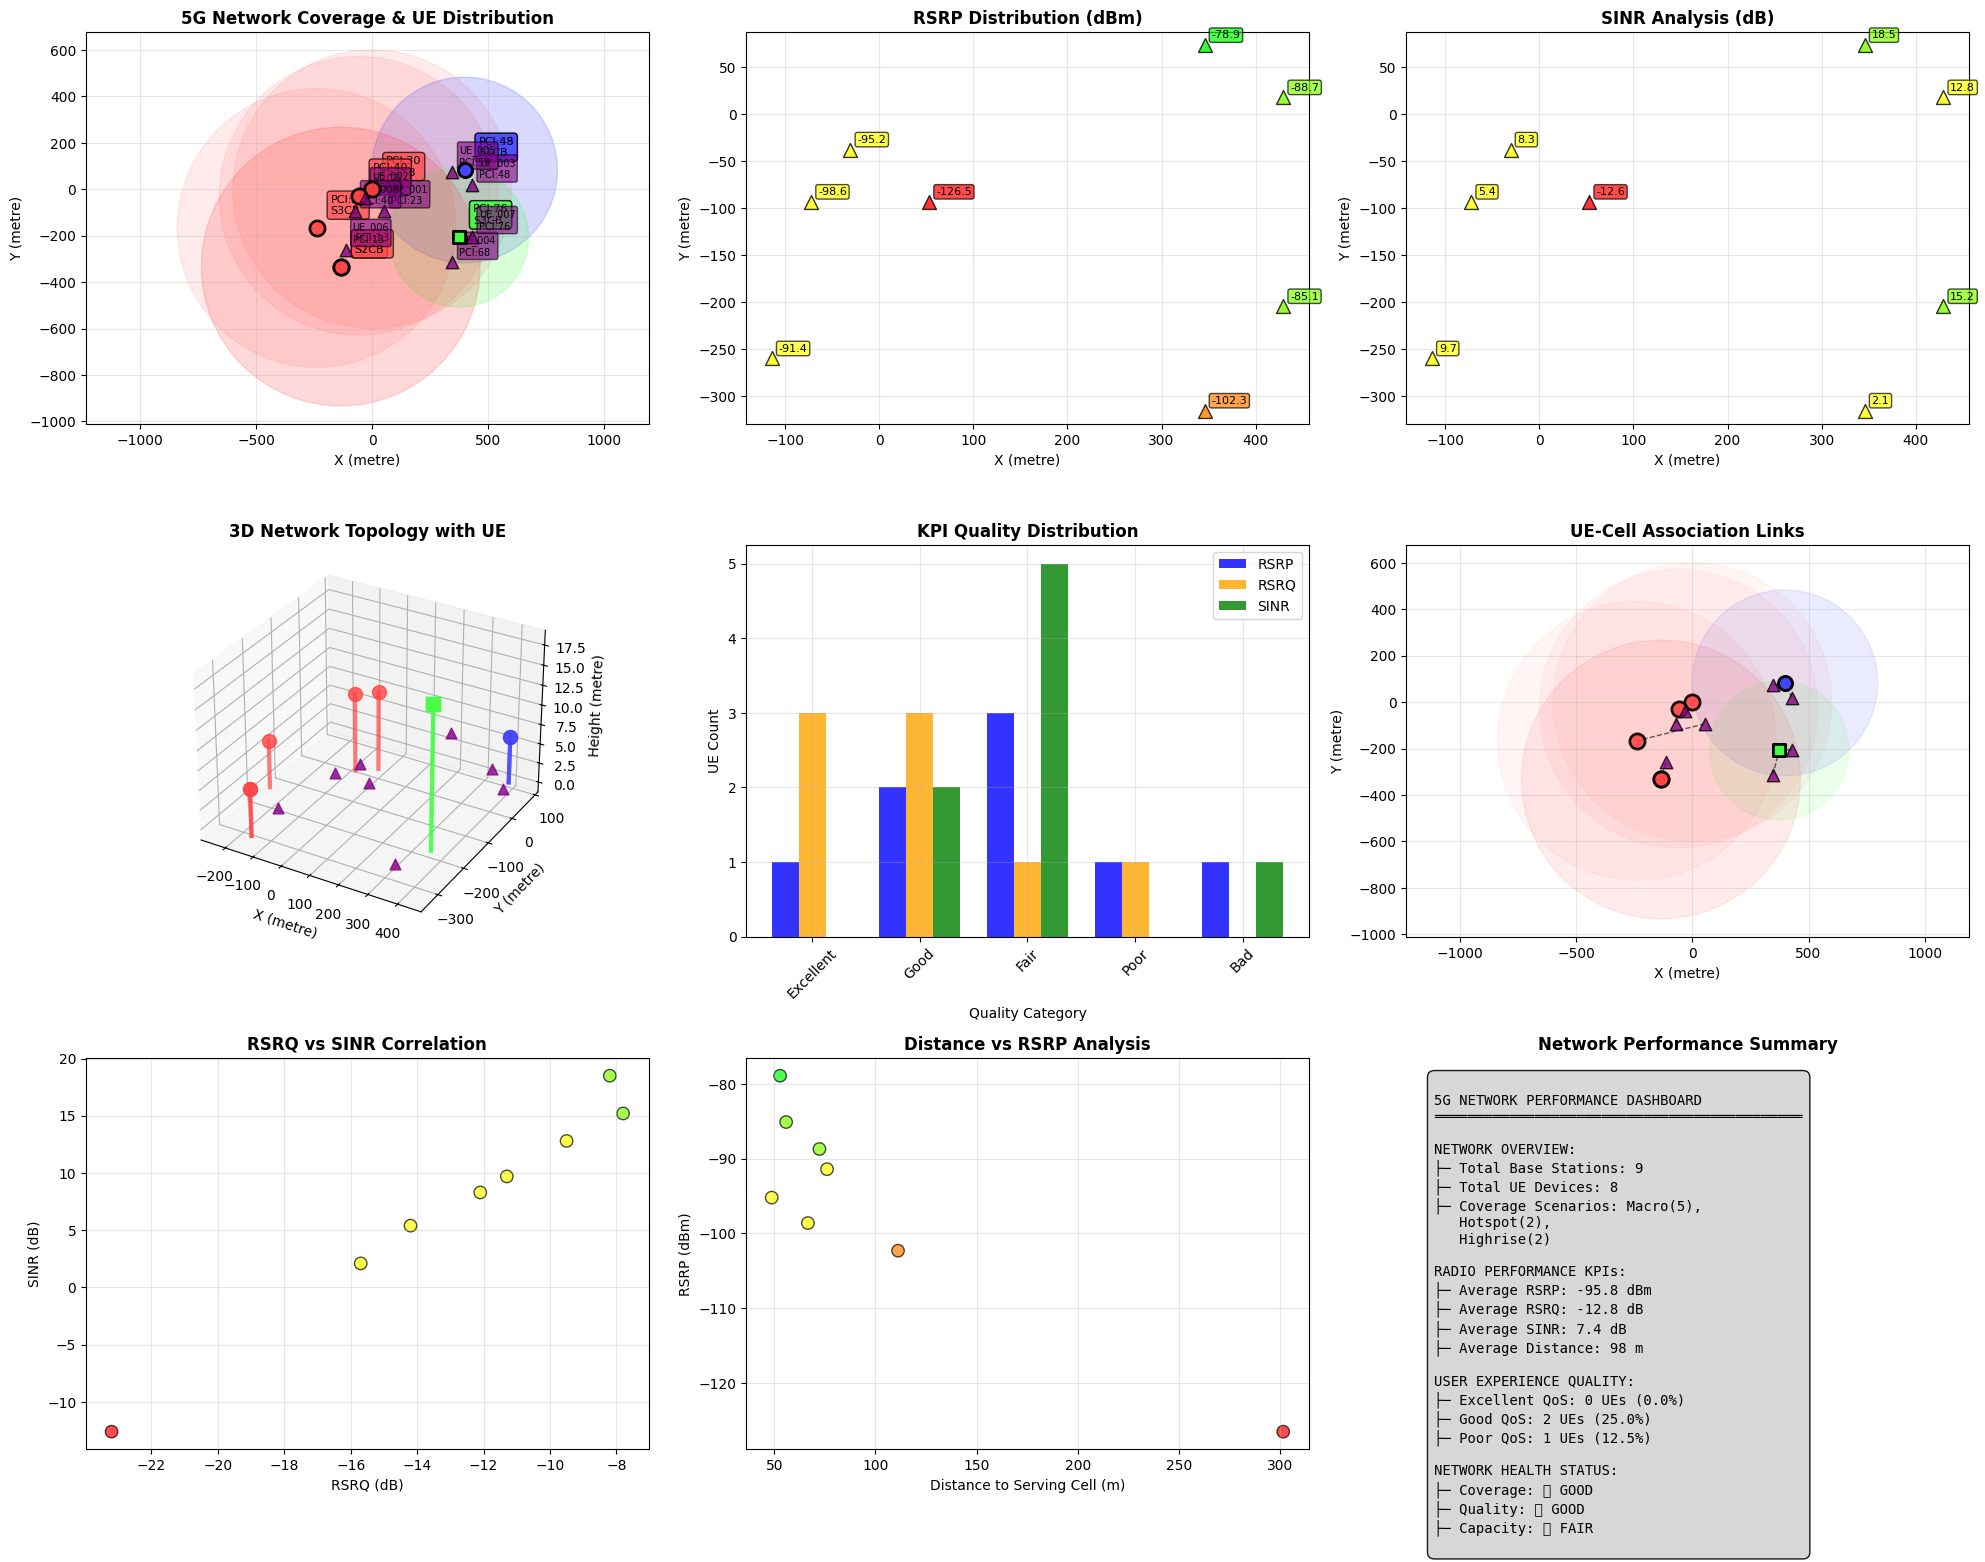


5G NETWORK UE PERFORMANCE ANALYSIS REPORT

UE_ID    PCI  RSRP     RSRQ     SINR     Distance   Quality      Serving_Cell        
----------------------------------------------------------------------------------------------------
UE_001   23   -126.5   -23.2    -12.6    301        Bad          WITUPAG-AAS-S3CB    
UE_002   30   -95.2    -12.1    8.3      49         Fair         WITUFERG-AAS-S1CB   
UE_003   48   -88.7    -9.5     12.8     72         Good         WITUFESG-AAS-S1CB   
UE_004   68   -102.3   -15.7    2.1      111        Poor         WITUFESG-AAS-S2CB   
UE_005   59   -78.9    -8.2     18.5     53         Excellent    WITUFERG-AAS-S3CB   
UE_006   13   -91.4    -11.3    9.7      76         Fair         WITUPAG-AAS-S2CB    
UE_007   76   -85.1    -7.8     15.2     56         Good         WITUFESG-AAS-S3CB   
UE_008   40   -98.6    -14.2    5.4      67         Fair         WITUFERG-AAS-S2CB   

SUMMARY STATISTICS:           
Average RSRP:                  -95.84 dBm
Average

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

# Kabinet verileri
kabinets = [
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1073413,
        "Longitude": 29.0233668,
        "Azimuth": 50,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 10,
        "MIMO": "64T64R",
        "PCI": 30,
        "rachroot": 26,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    },
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1070873,
        "Longitude": 29.0226646,
        "Azimuth": 260,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 10,
        "MIMO": "64T64R",
        "PCI": 40,
        "rachroot": 126,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    },
    {
        "Kabinet": "WITUFERG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1080861,
        "Longitude": 29.028122,
        "Azimuth": 230,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 59,
        "rachroot": 42,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Hotspot"
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1080861,
        "Longitude": 29.0281222,
        "Azimuth": 110,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 48,
        "rachroot": 69,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Hotspot"
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1054694,
        "Longitude": 29.0278333,
        "Azimuth": 255,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 9.5,
        "Height": 18,
        "MIMO": "32T32R",
        "PCI": 68,
        "rachroot": 132,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Highrise"
    },
    {
        "Kabinet": "WITUFESG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1054694,
        "Longitude": 29.0278333,
        "Azimuth": 340,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 9.5,
        "Height": 18,
        "MIMO": "32T32R",
        "PCI": 76,
        "rachroot": 75,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Highrise"
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S1CB",
        "Latitude": 41.1043417,
        "Longitude": 29.021747,
        "Azimuth": 300,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 3,
        "rachroot": 30,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S2CB",
        "Latitude": 41.1043417,
        "Longitude": 29.021747,
        "Azimuth": 40,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 13,
        "rachroot": 130,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    },
    {
        "Kabinet": "WITUPAG",
        "Sector": "AAS-S3CB",
        "Latitude": 41.1058417,
        "Longitude": 29.0205028,
        "Azimuth": 130,
        "Horizontal_Beamwidth": 65,
        "Vertical_Beamwidth": 10,
        "Height": 6,
        "MIMO": "64T64R",
        "PCI": 23,
        "rachroot": 93,
        "Power": 200,
        "Ssbpower": 17.91,
        "Scenario": "Macro"
    }
]

# UE (Receiver) verileri - network içinde dağılmış kullanıcılar
receivers = [
    {
        "UE_ID": "UE_001",
        "Latitude": 41.1065000,
        "Longitude": 29.0240000,
        "Height": 1.5,  # UE yüksekliği
        "NR_UE_PCI_0": 23.0,
        "NR_UE_RSRP_0": -126.5,
        "NR_UE_RSRQ_0": -23.2,
        "NR_UE_SINR_0": -12.6,
        "Serving_Cell": "WITUPAG-AAS-S3CB"
    },
    {
        "UE_ID": "UE_002",
        "Latitude": 41.1070000,
        "Longitude": 29.0230000,
        "Height": 1.5,
        "NR_UE_PCI_0": 30.0,
        "NR_UE_RSRP_0": -95.2,
        "NR_UE_RSRQ_0": -12.1,
        "NR_UE_SINR_0": 8.3,
        "Serving_Cell": "WITUFERG-AAS-S1CB"
    },
    {
        "UE_ID": "UE_003",
        "Latitude": 41.1075000,
        "Longitude": 29.0285000,
        "Height": 1.5,
        "NR_UE_PCI_0": 48.0,
        "NR_UE_RSRP_0": -88.7,
        "NR_UE_RSRQ_0": -9.5,
        "NR_UE_SINR_0": 12.8,
        "Serving_Cell": "WITUFESG-AAS-S1CB"
    },
    {
        "UE_ID": "UE_004",
        "Latitude": 41.1045000,
        "Longitude": 29.0275000,
        "Height": 1.5,
        "NR_UE_PCI_0": 68.0,
        "NR_UE_RSRP_0": -102.3,
        "NR_UE_RSRQ_0": -15.7,
        "NR_UE_SINR_0": 2.1,
        "Serving_Cell": "WITUFESG-AAS-S2CB"
    },
    {
        "UE_ID": "UE_005",
        "Latitude": 41.1080000,
        "Longitude": 29.0275000,
        "Height": 1.5,
        "NR_UE_PCI_0": 59.0,
        "NR_UE_RSRP_0": -78.9,
        "NR_UE_RSRQ_0": -8.2,
        "NR_UE_SINR_0": 18.5,
        "Serving_Cell": "WITUFERG-AAS-S3CB"
    },
    {
        "UE_ID": "UE_006",
        "Latitude": 41.1050000,
        "Longitude": 29.0220000,
        "Height": 1.5,
        "NR_UE_PCI_0": 13.0,
        "NR_UE_RSRP_0": -91.4,
        "NR_UE_RSRQ_0": -11.3,
        "NR_UE_SINR_0": 9.7,
        "Serving_Cell": "WITUPAG-AAS-S2CB"
    },
    {
        "UE_ID": "UE_007",
        "Latitude": 41.1055000,
        "Longitude": 29.0285000,
        "Height": 15.0,  # Yüksek kattaki kullanıcı
        "NR_UE_PCI_0": 76.0,
        "NR_UE_RSRP_0": -85.1,
        "NR_UE_RSRQ_0": -7.8,
        "NR_UE_SINR_0": 15.2,
        "Serving_Cell": "WITUFESG-AAS-S3CB"
    },
    {
        "UE_ID": "UE_008",
        "Latitude": 41.1065000,
        "Longitude": 29.0225000,
        "Height": 1.5,
        "NR_UE_PCI_0": 40.0,
        "NR_UE_RSRP_0": -98.6,
        "NR_UE_RSRQ_0": -14.2,
        "NR_UE_SINR_0": 5.4,
        "Serving_Cell": "WITUFERG-AAS-S2CB"
    }
]

# 5G KPI Thresholds
kpi_thresholds = {
    "RSRP": {
        "Excellent": -80,
        "Good": -90,
        "Fair": -100,
        "Poor": -110,
        "Bad": -120
    },
    "RSRQ": {
        "Excellent": -10,
        "Good": -15,
        "Fair": -20,
        "Poor": -25,
        "Bad": -30
    },
    "SINR": {
        "Excellent": 20,
        "Good": 13,
        "Fair": 0,
        "Poor": -3,
        "Bad": -6
    }
}

def classify_kpi(value, kpi_type):
    """KPI değerini sınıflandır"""
    thresholds = kpi_thresholds[kpi_type]
    if kpi_type == "SINR":
        if value >= thresholds["Excellent"]: return "Excellent", '#00FF00'
        elif value >= thresholds["Good"]: return "Good", '#7FFF00'
        elif value >= thresholds["Fair"]: return "Fair", '#FFFF00'
        elif value >= thresholds["Poor"]: return "Poor", '#FF7F00'
        else: return "Bad", '#FF0000'
    else:  # RSRP ve RSRQ için (negatif değerler)
        if value >= thresholds["Excellent"]: return "Excellent", '#00FF00'
        elif value >= thresholds["Good"]: return "Good", '#7FFF00'
        elif value >= thresholds["Fair"]: return "Fair", '#FFFF00'
        elif value >= thresholds["Poor"]: return "Poor", '#FF7F00'
        else: return "Bad", '#FF0000'

def lat_lon_to_xy(lat, lon, origin_lat, origin_lon):
    """Coğrafi koordinatları yerel kartezyen koordinatlara dönüştür"""
    x = (lon - origin_lon) * 111000 * math.cos(math.radians(origin_lat))
    y = (lat - origin_lat) * 111000
    return x, y

def calculate_distance(x1, y1, x2, y2):
    """İki nokta arası mesafe"""
    return math.sqrt((x2-x1)**2 + (y2-y1)**2)

def find_serving_cell_tx(serving_cell_name, kabinets):
    """Serving cell bilgisine göre transmitter bul"""
    for tx in kabinets:
        tx_name = f"{tx['Kabinet']}-{tx['Sector']}"
        if tx_name == serving_cell_name:
            return tx
    return None

# Görselleştirme
fig = plt.figure(figsize=(20, 16))

# Ana coverage haritası
ax1 = plt.subplot(3, 3, 1)
ax1.set_title('5G Network Coverage & UE Distribution', fontsize=12, fontweight='bold')

# RSRP Heatmap
ax2 = plt.subplot(3, 3, 2)
ax2.set_title('RSRP Distribution (dBm)', fontsize=12, fontweight='bold')

# SINR Analysis  
ax3 = plt.subplot(3, 3, 3)
ax3.set_title('SINR Analysis (dB)', fontsize=12, fontweight='bold')

# 3D Network with UE
ax4 = plt.subplot(3, 3, 4, projection='3d')
ax4.set_title('3D Network Topology with UE', fontsize=12, fontweight='bold')

# KPI Distribution
ax5 = plt.subplot(3, 3, 5)
ax5.set_title('KPI Quality Distribution', fontsize=12, fontweight='bold')

# UE-Cell Association
ax6 = plt.subplot(3, 3, 6)
ax6.set_title('UE-Cell Association Links', fontsize=12, fontweight='bold')

# RSRQ vs SINR Scatter
ax7 = plt.subplot(3, 3, 7)
ax7.set_title('RSRQ vs SINR Correlation', fontsize=12, fontweight='bold')

# Distance vs RSRP
ax8 = plt.subplot(3, 3, 8)
ax8.set_title('Distance vs RSRP Analysis', fontsize=12, fontweight='bold')

# Network Performance Summary
ax9 = plt.subplot(3, 3, 9)
ax9.set_title('Network Performance Summary', fontsize=12, fontweight='bold')

# Referans noktası
origin_lat = kabinets[0]["Latitude"]
origin_lon = kabinets[0]["Longitude"]

# Renkler
scenario_colors = {
    "Macro": '#FF4444',
    "Hotspot": '#4444FF',    
    "Highrise": '#44FF44'
}

# Transmitter'ları çiz
tx_positions = {}
for i, tx in enumerate(kabinets):
    x, y = lat_lon_to_xy(tx["Latitude"], tx["Longitude"], origin_lat, origin_lon)
    tx_positions[f"{tx['Kabinet']}-{tx['Sector']}"] = (x, y)
    
    scenario = tx["Scenario"]
    color = scenario_colors[scenario]
    
    # Coverage area (basitleştirilmiş)
    coverage_radius = 600 if scenario == "Macro" else 400 if scenario == "Hotspot" else 300
    circle = plt.Circle((x, y), coverage_radius, color=color, alpha=0.1)
    ax1.add_patch(circle)
    ax6.add_patch(plt.Circle((x, y), coverage_radius, color=color, alpha=0.05))
    
    # Transmitter marker
    marker_size = 120 if scenario == "Macro" else 100 if scenario == "Hotspot" else 80
    ax1.scatter(x, y, c=color, s=marker_size, alpha=0.9, edgecolors='black', linewidth=2,
               marker='o' if tx["MIMO"] == "64T64R" else 's', zorder=5)
    ax6.scatter(x, y, c=color, s=marker_size, alpha=0.9, edgecolors='black', linewidth=2,
               marker='o' if tx["MIMO"] == "64T64R" else 's', zorder=5)
    
    # Transmitter labels
    ax1.annotate(f'PCI:{tx["PCI"]}\n{tx["Sector"].split("-")[1]}', 
                xy=(x, y), xytext=(10, 10), textcoords='offset points',
                fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7))
    
    # 3D Plot
    ax4.scatter(x, y, tx["Height"], c=color, s=100, alpha=0.8,
                marker='o' if tx["MIMO"] == "64T64R" else 's')
    ax4.plot([x, x], [y, y], [0, tx["Height"]], color=color, alpha=0.7, linewidth=3)

# UE (Receiver) analizi
rsrp_values = []
rsrq_values = []
sinr_values = []
distances = []

for ue in receivers:
    x_ue, y_ue = lat_lon_to_xy(ue["Latitude"], ue["Longitude"], origin_lat, origin_lon)
    
    # Serving cell bulma ve mesafe hesaplama
    serving_tx = find_serving_cell_tx(ue["Serving_Cell"], kabinets)
    if serving_tx:
        x_tx, y_tx = lat_lon_to_xy(serving_tx["Latitude"], serving_tx["Longitude"], origin_lat, origin_lon)
        distance = calculate_distance(x_ue, y_ue, x_tx, y_tx)
        distances.append(distance)
        
        # Association line
        ax6.plot([x_ue, x_tx], [y_ue, y_tx], 'k--', alpha=0.6, linewidth=1)
    else:
        distances.append(0)
    
    # KPI sınıflandırması
    rsrp_class, rsrp_color = classify_kpi(ue["NR_UE_RSRP_0"], "RSRP")
    rsrq_class, rsrq_color = classify_kpi(ue["NR_UE_RSRQ_0"], "RSRQ")
    sinr_class, sinr_color = classify_kpi(ue["NR_UE_SINR_0"], "SINR")
    
    # UE pozisyonları - farklı plotlarda farklı renkler
    ax1.scatter(x_ue, y_ue, c='purple', s=80, marker='^', alpha=0.8, edgecolors='black', zorder=10)
    ax2.scatter(x_ue, y_ue, c=rsrp_color, s=100, marker='^', alpha=0.8, edgecolors='black', zorder=10)
    ax3.scatter(x_ue, y_ue, c=sinr_color, s=100, marker='^', alpha=0.8, edgecolors='black', zorder=10)
    ax6.scatter(x_ue, y_ue, c='purple', s=80, marker='^', alpha=0.8, edgecolors='black', zorder=10)
    
    # UE labels
    ax1.annotate(f'{ue["UE_ID"]}\nPCI:{int(ue["NR_UE_PCI_0"])}', 
                xy=(x_ue, y_ue), xytext=(5, 5), textcoords='offset points',
                fontsize=7, bbox=dict(boxstyle="round,pad=0.2", facecolor='purple', alpha=0.6))
    
    ax2.annotate(f'{ue["NR_UE_RSRP_0"]:.1f}', 
                xy=(x_ue, y_ue), xytext=(5, 5), textcoords='offset points',
                fontsize=8, bbox=dict(boxstyle="round,pad=0.2", facecolor=rsrp_color, alpha=0.7))
    
    ax3.annotate(f'{ue["NR_UE_SINR_0"]:.1f}', 
                xy=(x_ue, y_ue), xytext=(5, 5), textcoords='offset points',
                fontsize=8, bbox=dict(boxstyle="round,pad=0.2", facecolor=sinr_color, alpha=0.7))
    
    # 3D UE
    ax4.scatter(x_ue, y_ue, ue["Height"], c='purple', s=60, marker='^', alpha=0.8)
    
    # Veri toplama
    rsrp_values.append(ue["NR_UE_RSRP_0"])
    rsrq_values.append(ue["NR_UE_RSRQ_0"])
    sinr_values.append(ue["NR_UE_SINR_0"])

# Plot ayarları
for ax in [ax1, ax2, ax3, ax6]:
    ax.set_xlabel('X (metre)')
    ax.set_ylabel('Y (metre)')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

# 3D plot ayarları
ax4.set_xlabel('X (metre)')
ax4.set_ylabel('Y (metre)')
ax4.set_zlabel('Height (metre)')
ax4.grid(True, alpha=0.3)

# KPI Quality Distribution
kpi_categories = ["Excellent", "Good", "Fair", "Poor", "Bad"]
kpi_colors = ['#00FF00', '#7FFF00', '#FFFF00', '#FF7F00', '#FF0000']

rsrp_counts = [sum(1 for val in rsrp_values if classify_kpi(val, "RSRP")[0] == cat) for cat in kpi_categories]
rsrq_counts = [sum(1 for val in rsrq_values if classify_kpi(val, "RSRQ")[0] == cat) for cat in kpi_categories]
sinr_counts = [sum(1 for val in sinr_values if classify_kpi(val, "SINR")[0] == cat) for cat in kpi_categories]

x_pos = np.arange(len(kpi_categories))
width = 0.25

bars1 = ax5.bar(x_pos - width, rsrp_counts, width, label='RSRP', alpha=0.8, color='blue')
bars2 = ax5.bar(x_pos, rsrq_counts, width, label='RSRQ', alpha=0.8, color='orange')
bars3 = ax5.bar(x_pos + width, sinr_counts, width, label='SINR', alpha=0.8, color='green')

ax5.set_xlabel('Quality Category')
ax5.set_ylabel('UE Count')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(kpi_categories, rotation=45)
ax5.legend()
ax5.grid(True, alpha=0.3)

# RSRQ vs SINR Scatter
scatter_colors = [classify_kpi(val, "SINR")[1] for val in sinr_values]
scatter = ax7.scatter(rsrq_values, sinr_values, c=scatter_colors, s=80, alpha=0.7, edgecolors='black')
ax7.set_xlabel('RSRQ (dB)')
ax7.set_ylabel('SINR (dB)')
ax7.grid(True, alpha=0.3)

# Distance vs RSRP
distance_colors = [classify_kpi(val, "RSRP")[1] for val in rsrp_values]
ax8.scatter(distances, rsrp_values, c=distance_colors, s=80, alpha=0.7, edgecolors='black')
ax8.set_xlabel('Distance to Serving Cell (m)')
ax8.set_ylabel('RSRP (dBm)')
ax8.grid(True, alpha=0.3)

# Network Performance Summary
ax9.axis('off')
avg_rsrp = np.mean(rsrp_values)
avg_rsrq = np.mean(rsrq_values)
avg_sinr = np.mean(sinr_values)
avg_distance = np.mean(distances)

excellent_ues = sum(1 for val in sinr_values if classify_kpi(val, "SINR")[0] == "Excellent")
good_ues = sum(1 for val in sinr_values if classify_kpi(val, "SINR")[0] == "Good")
poor_ues = sum(1 for val in sinr_values if classify_kpi(val, "SINR")[0] in ["Poor", "Bad"])

summary_text = f"""
5G NETWORK PERFORMANCE DASHBOARD
════════════════════════════════════════════

NETWORK OVERVIEW:
├─ Total Base Stations: {len(kabinets)}
├─ Total UE Devices: {len(receivers)}
├─ Coverage Scenarios: Macro({sum(1 for tx in kabinets if tx['Scenario'] == 'Macro')}), 
   Hotspot({sum(1 for tx in kabinets if tx['Scenario'] == 'Hotspot')}), 
   Highrise({sum(1 for tx in kabinets if tx['Scenario'] == 'Highrise')})

RADIO PERFORMANCE KPIs:
├─ Average RSRP: {avg_rsrp:.1f} dBm
├─ Average RSRQ: {avg_rsrq:.1f} dB  
├─ Average SINR: {avg_sinr:.1f} dB
├─ Average Distance: {avg_distance:.0f} m

USER EXPERIENCE QUALITY:
├─ Excellent QoS: {excellent_ues} UEs ({excellent_ues/len(receivers)*100:.1f}%)
├─ Good QoS: {good_ues} UEs ({good_ues/len(receivers)*100:.1f}%)
├─ Poor QoS: {poor_ues} UEs ({poor_ues/len(receivers)*100:.1f}%)

NETWORK HEALTH STATUS:
├─ Coverage: {"🟢 GOOD" if avg_rsrp > -100 else "🟡 FAIR" if avg_rsrp > -110 else "🔴 POOR"}
├─ Quality: {"🟢 GOOD" if avg_rsrq > -15 else "🟡 FAIR" if avg_rsrq > -20 else "🔴 POOR"}  
├─ Capacity: {"🟢 GOOD" if avg_sinr > 10 else "🟡 FAIR" if avg_sinr > 0 else "🔴 POOR"}
"""

ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgray', alpha=0.9))

plt.tight_layout()
plt.show()

# Detaylı UE raporu
print("\n" + "="*100)
print("5G NETWORK UE PERFORMANCE ANALYSIS REPORT")
print("="*100)

print(f"\n{'UE_ID':<8} {'PCI':<4} {'RSRP':<8} {'RSRQ':<8} {'SINR':<8} {'Distance':<10} {'Quality':<12} {'Serving_Cell':<20}")
print("-"*100)

for i, ue in enumerate(receivers):
    rsrp_quality = classify_kpi(ue["NR_UE_RSRP_0"], "RSRP")[0]
    distance = distances[i] if i < len(distances) else 0
    
    print(f"{ue['UE_ID']:<8} {int(ue['NR_UE_PCI_0']):<4} {ue['NR_UE_RSRP_0']:<8.1f} "
          f"{ue['NR_UE_RSRQ_0']:<8.1f} {ue['NR_UE_SINR_0']:<8.1f} {distance:<10.0f} "
          f"{rsrp_quality:<12} {ue['Serving_Cell']:<20}")

print(f"\n{'SUMMARY STATISTICS:':<30}")
print(f"{'Average RSRP:':<30} {avg_rsrp:.2f} dBm")
print(f"{'Average RSRQ:':<30} {avg_rsrq:.2f} dB")
print(f"{'Average SINR:':<30} {avg_sinr:.2f} dB")
print(f"{'Best SINR UE:':<30} {max(receivers, key=lambda x: x['NR_UE_SINR_0'])['UE_ID']} ({max(sinr_values):.1f} dB)")
print(f"{'Worst SINR UE:':<30} {min(receivers, key=lambda x: x['NR_UE_SINR_0'])['UE_ID']} ({min(sinr_values):.1f} dB)")